# 1. Introduction

In data science, not all problems fit traditional models like classification or regression. Tasks involving nuanced language or semantic understanding require more than pattern recognition. In such cases, large language models (LLMs), with their ability to grasp context and intent, are essential. Data scientists must know when to move beyond conventional models and apply LLMs for deeper comprehension.

To understand the limits of traditional methods and the importance of semantic reasoning, we'll work with the SWAG dataset—over 113,000 multiple-choice questions based on real-world scenarios. This task will help us explore how LLMs excel at complex inference beyond simple patterns, reinforcing the value of foundation models in practical data science.

# 2. Environment Setup

## 2.1 Install Requirements

In [1]:
! pip install -U -q datasets

## 2.2 Import Libraries

In [89]:
import os
import warnings
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from copy import deepcopy
from typing import Callable, List, Dict, Any
from tabulate import tabulate
from tqdm import tqdm
from huggingface_hub import login
from datasets import load_dataset, DatasetDict
from transformers import (
    PreTrainedTokenizer, DataCollatorForMultipleChoice, PreTrainedTokenizerBase,
    AutoTokenizer, AutoModelForMultipleChoice, PreTrainedModel, 
    SchedulerType, get_scheduler
)
from sklearn.metrics import accuracy_score, confusion_matrix
from torch.utils.data import DataLoader
from torch.optim import AdamW
from peft import LoraConfig, get_peft_model, TaskType 

## 2.3 Configuration

In [4]:
warnings.filterwarnings("ignore", message="The secret `HF_TOKEN` does not exist in your Colab secrets.")

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 3. Utils

## 3.1 Text

In [7]:
def count_words(text):
  return len(text.split())

## 3.2 Tensor

In [8]:
def prepare_mc_input_tensor(v):
  if isinstance(v, list) and isinstance(v[0], torch.Tensor):
    return torch.stack(v).unsqueeze(0).to(device)
  elif isinstance(v, torch.Tensor):
    return v.unsqueeze(0).to(device)

# 4. Hugging Face

## 4.1 Login

In [10]:
hf_token = os.getenv('HUGGING_FACE_ACCESS_TOKEN')

In [11]:
login(token=hf_token)

# 5. Loading Dataset

Given a partial description like "she opened the hood of the car," humans can reason about the situation and anticipate what might come next ("then, she examined the engine"). SWAG (Situations With Adversarial Generations) is a large-scale dataset for this task of grounded commonsense inference, unifying natural language inference and physically grounded reasoning.

The dataset consists of 113k multiple choice questions about grounded situations (73k training, 20k validation, 20k test). Each question is a video caption from LSMDC or ActivityNet Captions, with four answer choices about what might happen next in the scene. The correct answer is the (real) video caption for the next event in the video; the three incorrect answers are adversarially generated and human verified, so as to fool machines but not humans. SWAG aims to be a benchmark for evaluating grounded commonsense NLI and for learning representations.

There is [dataset link](https://huggingface.co/datasets/allenai/swag)

In [12]:
swag_dataset = load_dataset("swag", "regular")

README.md: 0.00B [00:00, ?B/s]

regular/train-00000-of-00001.parquet:   0%|          | 0.00/14.8M [00:00<?, ?B/s]

regular/validation-00000-of-00001.parque(…):   0%|          | 0.00/4.81M [00:00<?, ?B/s]

regular/test-00000-of-00001.parquet:   0%|          | 0.00/4.78M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/73546 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/20006 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/20005 [00:00<?, ? examples/s]

In [13]:
swag_dataset

DatasetDict({
    train: Dataset({
        features: ['video-id', 'fold-ind', 'startphrase', 'sent1', 'sent2', 'gold-source', 'ending0', 'ending1', 'ending2', 'ending3', 'label'],
        num_rows: 73546
    })
    validation: Dataset({
        features: ['video-id', 'fold-ind', 'startphrase', 'sent1', 'sent2', 'gold-source', 'ending0', 'ending1', 'ending2', 'ending3', 'label'],
        num_rows: 20006
    })
    test: Dataset({
        features: ['video-id', 'fold-ind', 'startphrase', 'sent1', 'sent2', 'gold-source', 'ending0', 'ending1', 'ending2', 'ending3', 'label'],
        num_rows: 20005
    })
})

In [14]:
swag_train_df = swag_dataset['train'].to_pandas()
swag_val_df = swag_dataset['validation'].to_pandas()
swag_test_df = swag_dataset['test'].to_pandas()

# 6. EDA

In [16]:
swag_train_df.sample(3)

,video-id,fold-ind,startphrase,sent1,sent2,gold-source,ending0,ending1,ending2,ending3,label
37751,lsmdc3004_500_DAYS_OF_SUMMER-1653,11921,"In expectations, they're together, flirting. S...","In expectations, they're together, flirting.",Someone,gold,watches glumly as someone chats to two guys.,races across a courtyard and they climb up the...,pushes a heavy pressure bar with their fork.,greets her with a tanks kiss.,0
60231,anetv_XCJ2StGMgW4,8190,He is playing a set of bagpipes. He,He is playing a set of bagpipes.,He,gold,gets more and starts playing the game without ...,continues to play until he is finished.,starts playing the drums.,is swinging himself back and forth.,1
34676,lsmdc0009_Forrest_Gump-50606,8226,Someone rushes over to someone and pulls someo...,Someone rushes over to someone and pulls someo...,Someone,gold,nods and smiles at someone.,tries to help someone as he moans on the floor.,is sprawled out on the road as someone and the...,hurries to the tailgate.,1


In [17]:
print(f"Training set shape: {swag_train_df.shape}")
print(f"Column names: {list(swag_train_df.columns)}")
print(f"Data types:\n{swag_train_df.dtypes}")

Training set shape: (73546, 11)
Column names: ['video-id', 'fold-ind', 'startphrase', 'sent1', 'sent2', 'gold-source', 'ending0', 'ending1', 'ending2', 'ending3', 'label']
Data types:
video-id       object
fold-ind       object
startphrase    object
sent1          object
sent2          object
gold-source    object
ending0        object
ending1        object
ending2        object
ending3        object
label           int64
dtype: object


In [18]:
text_columns = ['sent1', 'sent2', 'ending0', 'ending1', 'ending2', 'ending3',]
swag_train_df[text_columns].describe()

,sent1,sent2,ending0,ending1,ending2,ending3
count,73546,73546,73546,73546,73546,73546
unique,52413,15767,69057,68960,68979,69189
top,The credits of the clip are shown.,Someone,see the ending title screen.,see the ending title screen.,talks to the camera.,talks to the camera.
freq,69,12818,22,23,19,21


In [19]:
print("WORD COUNT ANALYSIS")
print("="*30)

word_count_stats = {}
for col in text_columns:
    word_counts = swag_train_df[col].apply(count_words)
    word_count_stats[col] = {
        'mean': word_counts.mean(),
        'median': word_counts.median(),
        'std': word_counts.std(),
        'min': word_counts.min(),
        'max': word_counts.max()
    }

print("Word count statistics for training set:")
for col, stats in word_count_stats.items():
    print(f"\n{col}:")
    print(f"  Mean: {stats['mean']:.1f} words")
    print(f"  Median: {stats['median']:.1f} words")
    print(f"  Range: {stats['min']:.0f} - {stats['max']:.0f} words")

WORD COUNT ANALYSIS
Word count statistics for training set:

sent1:
  Mean: 11.4 words
  Median: 10.0 words
  Range: 3 - 66 words

sent2:
  Mean: 2.7 words
  Median: 2.0 words
  Range: 1 - 76 words

ending0:
  Mean: 8.6 words
  Median: 8.0 words
  Range: 1 - 25 words

ending1:
  Mean: 8.6 words
  Median: 8.0 words
  Range: 1 - 25 words

ending2:
  Mean: 8.6 words
  Median: 8.0 words
  Range: 1 - 25 words

ending3:
  Mean: 8.6 words
  Median: 8.0 words
  Range: 1 - 25 words


# 7. Preprocessing

Here is a preprocessing function that prepares the SWAG dataset for input into a language model:
1. Replicate the sent1 (context) field four times—once for each of the four endings.
2. Combine the replicated context with sent2 to complete the sentence setup.
3. Concatenate the result with each of the four candidate endings (ending0 to ending3)
to create four full input sequences per example.
4. Flatten the sequences and pass them through a Hugging Face tokenizer.
5. Unflatten the tokenized output so that each example retains a list of four candidate
encodings.
This structure ensures that each data point is aligned with the four-way multiple-choice format expected by models like BERT or RoBERTa in multiple-choice classification tasks.

In [20]:
def preprocess_swag_dataset(
    dataset: DatasetDict,
    tokenizer: PreTrainedTokenizer
) -> DatasetDict:

  def preprocess_batch(batch: Dict) -> Dict:
    first_sentences = [[context] * 4 for context in batch['sent1']]
    second_sentences = [[context] * 4 for context in batch['sent2']]
    all_endings = [
        [batch['ending0'][i], batch['ending1'][i], batch['ending2'][i], batch['ending3'][i]]
        for i in range(len(batch['sent1']))
    ]


    first_sentences = sum(first_sentences, [])
    second_sentences = sum(second_sentences, [])
    endings = sum(all_endings, [])

    tokenized = tokenizer(
        first_sentences,
        second_sentences,
        endings,
        padding=False,
        truncation=True,
        max_length=tokenizer.model_max_length,
    )

    unflattened = {
        k: [v[i:i+4] for i in range(0, len(v), 4)]
        for k, v in tokenized.items()
    }
    unflattened['labels'] = batch['label']
    unflattened.update({key: batch[key] for key in batch})
    return unflattened

  processed_dataset = DatasetDict()
  for split in dataset.keys():
    processed_dataset[split] = dataset[split].map(
        preprocess_batch,
        batched=True,
        remove_columns=dataset[split].column_names
    )

  return processed_dataset

In [21]:
bert_tokenizer = AutoTokenizer.from_pretrained("google-bert/bert-base-uncased")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [22]:
data_collator = DataCollatorForMultipleChoice(tokenizer=bert_tokenizer)

In [23]:
processed_swag_dataset = preprocess_swag_dataset(swag_dataset, bert_tokenizer)

Map:   0%|          | 0/73546 [00:00<?, ? examples/s]

Map:   0%|          | 0/20006 [00:00<?, ? examples/s]

Map:   0%|          | 0/20005 [00:00<?, ? examples/s]

In [24]:
processed_swag_dataset

DatasetDict({
    train: Dataset({
        features: ['video-id', 'fold-ind', 'startphrase', 'sent1', 'sent2', 'gold-source', 'ending0', 'ending1', 'ending2', 'ending3', 'label', 'input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 73546
    })
    validation: Dataset({
        features: ['video-id', 'fold-ind', 'startphrase', 'sent1', 'sent2', 'gold-source', 'ending0', 'ending1', 'ending2', 'ending3', 'label', 'input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 20006
    })
    test: Dataset({
        features: ['video-id', 'fold-ind', 'startphrase', 'sent1', 'sent2', 'gold-source', 'ending0', 'ending1', 'ending2', 'ending3', 'label', 'input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 20005
    })
})

# 8. Model

## 8.1 Loading Model

In [25]:
bert_model = AutoModelForMultipleChoice.from_pretrained("google-bert/bert-base-uncased")

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForMultipleChoice were not initialized from the model checkpoint at google-bert/bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [26]:
bert_model.to(device)

BertForMultipleChoice(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, ele

## 8.2 Test the model on the dataset

In [28]:
sample = processed_swag_dataset['validation'].shuffle().select([0])
sample.set_format("torch")
sample_dict = sample[0]

In [29]:
input_batch = {
    'input_ids': prepare_mc_input_tensor(sample_dict['input_ids']),
    'token_type_ids': prepare_mc_input_tensor(sample_dict['token_type_ids']),
    'attention_mask': prepare_mc_input_tensor(sample_dict['attention_mask']),
}

with torch.no_grad():
    outputs = bert_model(**input_batch)

predicted_label = torch.argmax(outputs.logits).item()
true_label = sample_dict['label']


context = sample_dict['sent1']
start = sample_dict['sent2']
endings = [
    sample_dict['ending0'],
    sample_dict['ending1'],
    sample_dict['ending2'],
    sample_dict['ending3']
]

print(f"\nContext: {context}")
print(f"\nStart: {start}")
print("\nOptions:")
for i, ending in enumerate(endings):
  print(f"{i}: {start} {ending}")

print(f"\nModel's prediction: Option {predicted_label}")
print(f"Correct answer: Option {true_label}")
print(f"Prediction is {'CORRECT' if predicted_label == true_label else 'INCORRECT'}")


print("\nModel's confidence scores:")
for i, score in enumerate(torch.softmax(outputs.logits, dim=1)[0]):
  print(f"Option {i}: {score.item():.4f}")


if predicted_label == true_label:
  print("\nThe model correctly identified the most plausible continuation.")
else:
  print("\nThe model failed to select the correct continuation.")


Context: They hold eye contact, and she lets go.

Start: As someone turns and walks away from the farmhouse, the woman

Options:
0: As someone turns and walks away from the farmhouse, the woman is careful not to approach the window.
1: As someone turns and walks away from the farmhouse, the woman 's jaw drops slack.
2: As someone turns and walks away from the farmhouse, the woman walks beside her to her.
3: As someone turns and walks away from the farmhouse, the woman continues to gaze after him.

Model's prediction: Option 0
Correct answer: Option 3
Prediction is INCORRECT

Model's confidence scores:
Option 0: 0.2500
Option 1: 0.2500
Option 2: 0.2500
Option 3: 0.2500

The model failed to select the correct continuation.


All options have equal confidence (0.25), meaning the model had no preference among them. This suggests the model was completely uncertain, effectively guessing randomly.

## 8.3 Simple Evaluation on Validation Dataset

In [30]:
validation_dataset = processed_swag_dataset["validation"]
validation_dataset.set_format(
    "torch",
    columns=["input_ids", "attention_mask", "labels",]
)
validation_dataloader = DataLoader(
    validation_dataset,
    batch_size=16,
    shuffle=False,
    collate_fn=data_collator
)

In [32]:
all_predictions = []
all_labels = []

with torch.no_grad():
  for batch in tqdm(validation_dataloader, desc="Evaluating"):
    batch = {k: v.to(device) for k, v in batch.items()}

    outputs = bert_model(**batch)
    logits = outputs.logits.cpu().numpy()
    labels = batch['labels'].cpu().numpy()

    predicted_choices = np.argmax(logits, axis=1)
    all_predictions.append(predicted_choices)
    all_labels.append(labels)


all_predictions = np.concatenate(all_predictions, axis=0)
all_labels = np.concatenate(all_labels, axis=0)
base_acc = accuracy_score(all_labels, all_predictions)
print(f"\nAccuracy: {base_acc:.4f} ({base_acc * 100:.2f}%)")

Evaluating: 100%|██████████| 1251/1251 [02:47<00:00,  7.45it/s]


Accuracy: 0.2466 (24.66%)


## 8.4 In Context Learning(ICL)

In-Context Learning (ICL) is a method where a model is given examples of tasks directly within its input prompt, enabling it to learn from these examples without updating its weights. Instead of fine-tuning the model, we provide a few example question-answer pairs, and the model uses them as guidance to make predictions on new questions.

| Technique                | Strengths                          | Limitations                     | Best For                      |
|--------------------------|------------------------------------|---------------------------------|-------------------------------|
| Zero-Shot CoT            | No examples needed                 | Requires careful prompting      | Math/reasoning tasks          |
| Few-Shot Learning        | Quick adaptation                   | Surface-level understanding     | Simple classification         |
| Instruction Tuning       | Follows complex instructions       | Needs human feedback data       | Open-ended tasks              |
| Gradient Descent Theory  | Explains ICL mechanics             | Theoretical, hard to implement  | Understanding model internals |

In [33]:
ICLFuncType = Callable[
    [PreTrainedModel, PreTrainedTokenizerBase, Any],
    Any
]

In [34]:
icl_val_data_loader = validation_dataloader = DataLoader(
    swag_dataset['validation'],
    batch_size=16,
    shuffle=False,
)

In [35]:
def evaluate_icl(
    model: PreTrainedModel,
    tokenizer: PreTrainedTokenizerBase,
    dataloader: DataLoader[Dict[str, torch.Tensor]],
    icl: ICLFuncType,
):
  all_predictions = []
  all_labels = []
  with torch.no_grad():
    for batch in tqdm(dataloader, desc=f"Evaluating"):
      labels = batch['label'].cpu().numpy()
      preds = icl(model, tokenizer, batch)
      all_predictions.append(np.array(preds))
      all_labels.append(labels)

  all_predictions = np.concatenate(all_predictions)
  all_labels = np.concatenate(all_labels)
  acc = accuracy_score(all_labels, all_predictions)
  return acc

### 8.4.1 Zero Shot

**Core Idea**: Adding simple reasoning prompts enables complex problem-solving without examples.

**Key Technique**: Zero-shot Chain-of-Thought (CoT) prompting
- Add phrases like "Let's think step by step" to questions
- Triggers the model's implicit reasoning capabilities

**Example**:
```
Q: If 3 pencils cost $6, how much do 5 pencils cost?
A: Let's think step by step.
```
**Model Output**:
```
1. First find cost per pencil: $6 ÷ 3 = $2 per pencil
2. Then calculate for 5 pencils: 5 × $2 = $10
Answer: $10
```

**Why It Works**: The prompt forces the model to:
1. Break down problems into steps
2. Apply arithmetic operations sequentially
3. Avoid jumping to incorrect answers

In [36]:
def format_prompt_zero_shot(sent1, sent2, endings):
  prompt_template = """
    Starting Context: {sent1}
    Continuation: {sent2}
    Which of the following best continues the sentence?\n
    Option: {ending}
  """
  return [
      prompt_template.format(sent1=sent1, sent2=sent2, ending=ending)
      for ending in endings
  ]

In [37]:
def zero_shot_icl(
    model: PreTrainedModel,
    tokenizer: PreTrainedTokenizerBase,
    batch
):
  model.eval()
  predictions = []

  batch_entries = zip(
      batch['sent1'],
      batch['sent2'],
      batch['ending0'],
      batch['ending1'],
      batch['ending2'],
      batch['ending3']
  )

  for sent1, sent2, e0, e1, e2, e3 in batch_entries:
    input_texts = format_prompt_zero_shot(sent1, sent2, [e0, e1, e2, e3])

    encoded = tokenizer(
        input_texts,
        padding=True,
        truncation=True,
        return_tensors="pt"
    )

    encoded = {k: v.unsqueeze(0).to(model.device) for k, v in encoded.items()}

    with torch.no_grad():
      logits = model(**encoded).logits
      pred = torch.argmax(logits, dim=1).item()

    predictions.append(pred)

  return predictions

In [39]:
zero_shot_icl_acc = evaluate_icl(bert_model, bert_tokenizer,
                                 icl_val_data_loader, zero_shot_icl)

Evaluating: 100%|██████████| 1251/1251 [05:15<00:00,  3.97it/s]


In [40]:
print(f"\nAccuracy: {zero_shot_icl_acc:.4f} ({zero_shot_icl_acc * 100:.2f}%)")


Accuracy: 0.1408 (14.08%)


### 8.4.2 Few Shot

**Core Idea**: Few-shot learning relies on surface patterns rather than deep understanding.

**Key Findings**:
- Models learn input-output formats, not concepts
- Performance drops when examples are misleading
- Primarily pattern matching, not true learning

**Example**:
```
Input: "Amazing!" → Sentiment: Foo
Input: "Terrible" → Sentiment: Bar
Input: "Mediocre" →
```
**Model Output**: (Predicts based on format, not meaning)
```
Sentiment: Baz
```

**Critical Insight**: The model:
1. Recognizes the label sequence (Foo, Bar, Baz)
2. Ignores actual sentiment meanings
3. Fails if labels are shuffled

In [41]:
few_shots_icl_examples = swag_val_df.sample(3)

In [42]:
def format_prompt_few_shot_icl(query) -> str:
  shots_prompt = ""

  for _, example in few_shots_icl_examples.iterrows():
    options = "\n".join([
        f"A) {example['ending0']}",
        f"B) {example['ending1']}",
        f"C) {example['ending2']}",
        f"D) {example['ending3']}"
    ])

    answer = chr(65 + example["label"])

    formatted_example = f"""
        Example:
        Context: {example['sent1']}
        Continuation: {example['sent2']}
        Options:
          {options}
        Correct Answer: {answer}
        ----------------------------------------
    """
    shots_prompt += formatted_example

  query_options = "\n".join(
      f"{chr(65 + i)}. {opt}"
      for i, opt in enumerate(query["endings"])
  )

  input_texts = []
  return f"""
      {shots_prompt}

      Query:
      Context: {query['sent1']}
      Continuation: {query['sent2']}
      Options:
        {query_options}
      Correct Answer:
  """

In [43]:
def few_shot_icl(
    model: PreTrainedModel,
    tokenizer: PreTrainedTokenizerBase,
    batch,
):
  model.eval()
  predictions = []

  batch_entries = zip(
      batch['sent1'],
      batch['sent2'],
      batch['ending0'],
      batch['ending1'],
      batch['ending2'],
      batch['ending3']
  )

  for sent1, sent2, e0, e1, e2, e3 in batch_entries:
    input_texts = format_prompt_few_shot_icl(
        query={
            "sent1": sent1,
            "sent2": sent2,
            "endings": [e0, e1, e2, e3]
        }
    )

    encoded = tokenizer(
        input_texts,
        padding=True,
        truncation=True,
        return_tensors="pt"
    )
    encoded = {k: v.unsqueeze(0).to(model.device) for k, v in encoded.items()}

    with torch.no_grad():
      logits = model(**encoded).logits
      pred = torch.argmax(logits, dim=1).item()

    predictions.append(pred)

  return predictions

In [44]:
few_shot_icl_acc = evaluate_icl(bert_model, bert_tokenizer,
                                icl_val_data_loader, few_shot_icl)

Evaluating: 100%|██████████| 1251/1251 [10:47<00:00,  1.93it/s]


In [45]:
print(f"\nAccuracy: {few_shot_icl_acc:.4f} ({few_shot_icl_acc * 100:.2f}%)")


Accuracy: 0.2466 (24.66%)


### 8.4.3 InstructGPT

**Core Idea**: Aligning models with human instructions improves task performance.

**Key Technique**: Instruction tuning via:
1. Supervised fine-tuning on human examples
2. Reinforcement learning from human feedback (RLHF)

**Example**:
```
Instruction: Write a formal email declining a meeting invitation.
Context: The meeting is on Friday about project Alpha.
```
**Model Output**:
```
Subject: Regarding Friday's Project Alpha Meeting  

Dear [Name],  

Thank you for the invitation. Unfortunately... [polish decline]  
```

**Why It Works**:
1. Learns from human-written examples
2. Generalizes to similar instructions
3. Produces more appropriate responses


### 8.4.4 Transformers Learn In-Context by Gradient Descent

**Core Idea**: ICL mimics gradient descent during forward passes.

**Key Mechanism**:
1. Attention heads act like weight updates
2. Forward pass simulates learning
3. Examples serve as "training data"

**Example**:
```
Input: cat → Output: meow
Input: dog → Output: woof
Input: bird →
```
**Model Output**:
```
tweet
```

**How It Works**:
1. Processes examples like a mini-dataset
2. "Learns" the mapping pattern
3. Applies it to new inputs

### 8.4.5 Compare Zero Shot ICL, Few Sht ICL and Base

In [46]:
data = [
    ["Base (Fine-tuned)", f"{base_acc * 100:.2f}%"],
    ["Zero-shot ICL", f"{zero_shot_icl_acc * 100:.2f}%"],
    ["Few-shot ICL", f"{few_shot_icl_acc * 100:.2f}%"]
]

print(tabulate(data, headers=["Method", "Accuracy"], tablefmt="github"))

| Method            | Accuracy   |
|-------------------|------------|
| Base (Fine-tuned) | 24.66%     |
| Zero-shot ICL     | 14.08%     |
| Few-shot ICL      | 24.66%     |


## 8.5 Fine Tuning

Fine-tuning is the process of taking a pretrained model (like BERT) and continuing to train it on a specific task or dataset. While BERT is trained on large amounts of general text data, it has not seen the specific format or reasoning patterns required by the SWAG dataset. By fine-tuning, we adjust the model’s internal weights to better align with the structure and
distribution of the SWAG data, helping it learn to predict more accurate answers for this particular task.

Without fine-tuning, the model relies purely on its general knowledge, which might not perfectly match the SWAG task. Fine-tuning allows the model to:
- Adapt to the specific question/answer format in SWAG.
- Learn common patterns in the contexts and endings of the dataset.
- Improve performance beyond what is achievable with zero-shot or in-context learning alone.

### 8.5.1 LoRA (Low-Rank Adaptation)

LoRA (Hu et al., 2021) introduces small, trainable low-rank matrices into the model’s architecture, allowing you to adapt the model to a new task without updating all of itsparameters. This dramatically reduces the memory and computational costs of fine-tuning large models like BERT.

Using LoRA enables you to:
- Fine-tune large models efficiently, even on limited hardware (like Kaggle GPUs).
- Save time and memory compared to full model fine-tuning.

### 8.5.2 Gradient Accumulation

When working with large models and limited GPU memory, it’s common to use gradientaccumulation. Instead of updating the model after every mini-batch, you accumulate gradients over multiple smaller batches and update the weights after a larger “virtual” batch. For example, if you want an effective batch size of 64 but can only fit 16 samples in memory, you can accumulate gradients over 4 steps before performing an update.

### 8.5.3 Implementation

In [55]:
fine_tuned_bert_model = deepcopy(bert_model)

In [49]:
lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules=["query", "value"],
    lora_dropout=0.1,
    bias="none",
    task_type=TaskType.SEQ_CLS
)

In [56]:
fine_tuned_bert_model = get_peft_model(fine_tuned_bert_model, lora_config)
fine_tuned_bert_model.print_trainable_parameters()

trainable params: 295,681 || all params: 109,778,690 || trainable%: 0.2693


In [57]:
batch_size_lora = 8
grad_accum_steps_lora = 4
learning_rate_lora = 2e-5
num_epochs_lora = 2

In [87]:
train_dataset_lora = processed_swag_dataset['train']
train_dataset_lora.set_format(
    "torch",
    columns=["input_ids", "attention_mask", "labels",]
)
train_dataloader_lora = DataLoader(train_dataset_lora,
                                   batch_size=batch_size_lora,
                                   shuffle=True,
                                  collate_fn=data_collator)
val_dataset_lora = processed_swag_dataset['validation']
val_dataset_lora.set_format(
    "torch",
    columns=["input_ids", "attention_mask", "labels",]
)
val_dataloader_lora = DataLoader(val_dataset_lora,
                                   batch_size=batch_size_lora,
                                   shuffle=True,
                                  collate_fn=data_collator)

In [83]:
optimizer_lora = AdamW(fine_tuned_bert_model.parameters(), lr=learning_rate_lora)
total_steps_lora = len(train_dataloader_lora) * num_epochs_lora // grad_accum_steps_lora
scheduler_lora = get_scheduler(
    name=SchedulerType.LINEAR,
    optimizer=optimizer_lora,
    num_warmup_steps=0.1 * total_steps_lora,
    num_training_steps=total_steps_lora,
)

In [84]:
def fine_tune_model(model, train_dataloader, val_dataloader, optimizer, scheduler, num_epochs, grad_accum_steps):
    best_val_accuracy = 0
    train_losses = []
    val_metrics = []
    
    for epoch in range(num_epochs):
        model.train()
        total_loss = 0
        optimizer.zero_grad()
        
        for step, batch in enumerate(train_dataloader):
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**batch)
            loss = outputs.loss
            loss = loss / grad_accum_steps
            loss.backward()
            
            if (step + 1) % grad_accum_steps == 0:
                optimizer.step()
                scheduler.step()
                optimizer.zero_grad()
            
            total_loss += loss.item() * grad_accum_steps
            
            if step % 100 == 0:
                print(f"Epoch {epoch+1}, Step {step}, Loss: {loss.item() * grad_accum_steps:.4f}")
        
        avg_train_loss = total_loss / len(train_dataloader)
        train_losses.append(avg_train_loss)

        val_results = evaluate_model(model, val_dataloader)
        val_metrics.append(val_results)
        
        print(f"\nEpoch {epoch+1} Results:")
        print(f"Train Loss: {avg_train_loss:.4f}")
        print(f"Validation Accuracy: {val_results['accuracy']:.4f}")
        print(f"Validation Perplexity: {val_results['perplexity']:.4f}")
    
    return train_losses, val_metrics

In [85]:
def evaluate_model(model, dataloader):
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for batch in dataloader:
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**batch)
            
            loss = outputs.loss
            total_loss += loss.item()
            
            logits = outputs.logits
            preds = torch.argmax(logits, dim=-1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(batch['labels'].cpu().numpy())
    
    avg_loss = total_loss / len(dataloader)
    perplexity = torch.exp(torch.tensor(avg_loss)).item()
    accuracy = accuracy_score(all_labels, all_preds)
    cm = confusion_matrix(all_labels, all_preds)
    
    return {
        'loss': avg_loss,
        'perplexity': perplexity,
        'accuracy': accuracy,
        'confusion_matrix': cm
    }

In [90]:
train_losses_lora, val_metrics_lora = fine_tune_model(
    fine_tuned_bert_model, train_dataloader_lora, val_dataloader_lora, 
    optimizer_lora, scheduler_lora, num_epochs_lora, grad_accum_steps_lora
)

Epoch 1, Step 0, Loss: 1.3881
Epoch 1, Step 100, Loss: 1.3852
Epoch 1, Step 200, Loss: 1.4676
Epoch 1, Step 300, Loss: 1.3854
Epoch 1, Step 400, Loss: 1.3936
Epoch 1, Step 500, Loss: 1.3573
Epoch 1, Step 600, Loss: 1.3612
Epoch 1, Step 700, Loss: 1.3742
Epoch 1, Step 800, Loss: 1.4434
Epoch 1, Step 900, Loss: 1.3687
Epoch 1, Step 1000, Loss: 1.3514
Epoch 1, Step 1100, Loss: 1.3761
Epoch 1, Step 1200, Loss: 1.3545
Epoch 1, Step 1300, Loss: 1.4125
Epoch 1, Step 1400, Loss: 1.4204
Epoch 1, Step 1500, Loss: 1.3463
Epoch 1, Step 1600, Loss: 1.3959
Epoch 1, Step 1700, Loss: 1.3751
Epoch 1, Step 1800, Loss: 1.3540
Epoch 1, Step 1900, Loss: 1.3963
Epoch 1, Step 2000, Loss: 1.3567
Epoch 1, Step 2100, Loss: 1.4033
Epoch 1, Step 2200, Loss: 1.4411
Epoch 1, Step 2300, Loss: 1.4103
Epoch 1, Step 2400, Loss: 1.3420
Epoch 1, Step 2500, Loss: 1.4668
Epoch 1, Step 2600, Loss: 1.3509
Epoch 1, Step 2700, Loss: 1.3560
Epoch 1, Step 2800, Loss: 1.3907
Epoch 1, Step 2900, Loss: 1.3677
Epoch 1, Step 3000, Lo

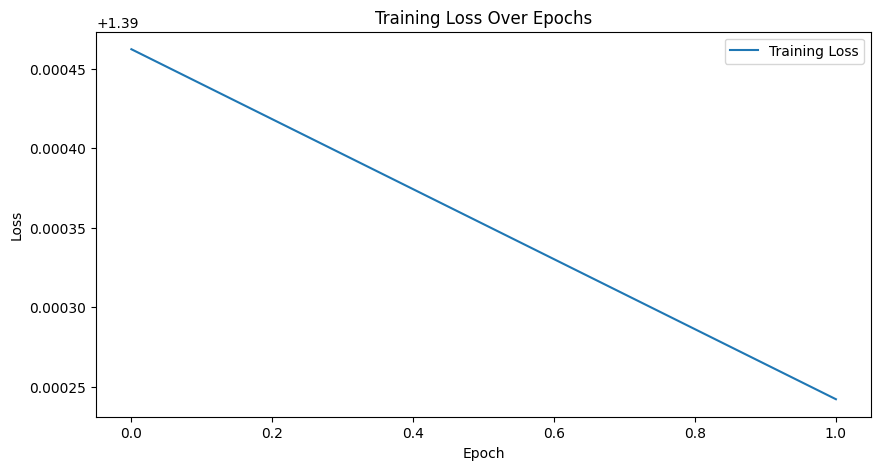

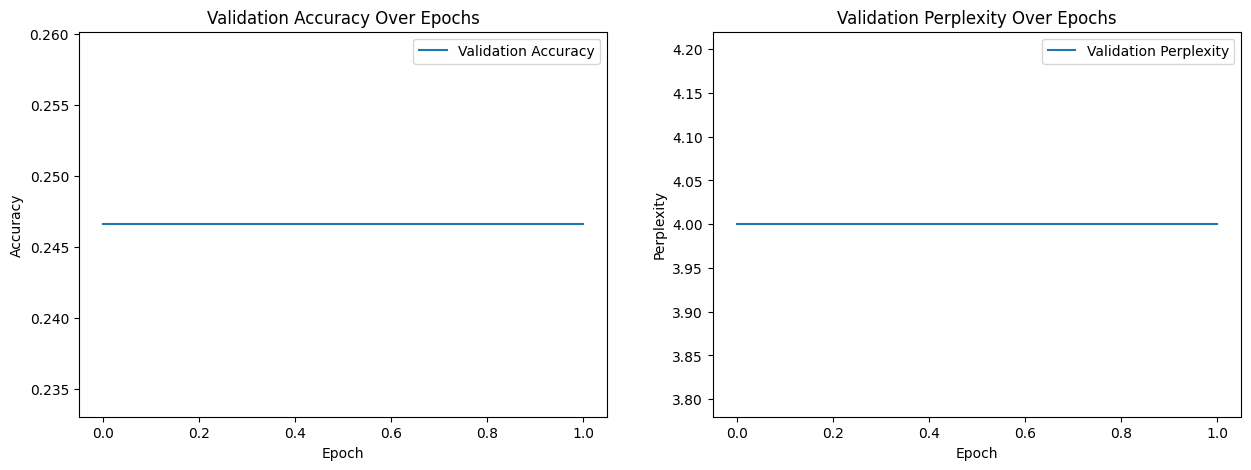

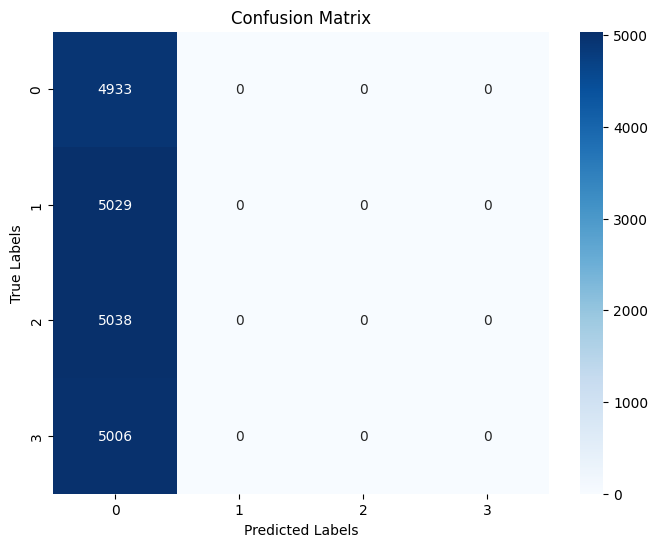


Final Validation Results:
Accuracy: 0.2466
Perplexity: 4.0000

Comparison with Baseline:
Baseline Accuracy: 0.2466
Fine-tuned Accuracy: 0.2466
Improvement: 0.0000


In [96]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses_lora, label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Over Epochs')
plt.legend()
plt.show()

plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.plot([m['accuracy'] for m in val_metrics_lora], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Validation Accuracy Over Epochs')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot([m['perplexity'] for m in val_metrics_lora], label='Validation Perplexity')
plt.xlabel('Epoch')
plt.ylabel('Perplexity')
plt.title('Validation Perplexity Over Epochs')
plt.legend()
plt.show()

cm = val_metrics_lora[-1]['confusion_matrix']
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()


print("\nFinal Validation Results:")
print(f"Accuracy: {val_metrics_lora[num_epochs_lora-1]['accuracy']:.4f}")
print(f"Perplexity: {val_metrics_lora[num_epochs_lora-1]['perplexity']:.4f}")

print("\nComparison with Baseline:")
print(f"Baseline Accuracy: {base_acc:.4f}")
print(f"Fine-tuned Accuracy: {val_metrics_lora[num_epochs_lora-1]['accuracy']:.4f}")
print(f"Improvement: {val_metrics_lora[num_epochs_lora-1]['accuracy'] - base_acc:.4f}")

## 8.6 ICL with Fine Tuning

In [97]:
zero_shot_icl_with_fine_tuned_acc = evaluate_icl(fine_tuned_bert_model,
                                                  bert_tokenizer,
                                                  icl_val_data_loader,
                                                  zero_shot_icl)

Evaluating: 100%|██████████| 1251/1251 [05:29<00:00,  3.80it/s]


In [98]:
few_shot_icl_with_fine_tuned_acc = evaluate_icl(fine_tuned_bert_model,
                                                 bert_tokenizer,
                                                 icl_val_data_loader,
                                                 few_shot_icl)

Evaluating: 100%|██████████| 1251/1251 [11:06<00:00,  1.88it/s]


## 8.7 Analyse The Result

In [99]:
data = [
    ["Base (Fine-tuned)", f"{base_acc * 100:.2f}%"],
    ["Zero-shot ICL", f"{zero_shot_icl_acc * 100:.2f}%"],
    ["Few-shot ICL", f"{few_shot_icl_acc * 100:.2f}%"],
    ["Zero-shot Fine Tuned ICL", f"{zero_shot_icl_with_fine_tuned_acc * 100:.2f}%"],
    ["Few-shot Fine Tuned ICL", f"{few_shot_icl_with_fine_tuned_acc * 100:.2f}%"]
]

print(tabulate(data, headers=["Method", "Accuracy"], tablefmt="github"))

| Method                   | Accuracy   |
|--------------------------|------------|
| Base (Fine-tuned)        | 24.66%     |
| Zero-shot ICL            | 14.08%     |
| Few-shot ICL             | 24.66%     |
| Zero-shot Fine Tuned ICL | 18.07%     |
| Few-shot Fine Tuned ICL  | 24.66%     |


Could there be cases where ICL introduces noise or distracts a model that’s already
specialized on a task?

Yes, in-context learning (ICL) can introduce noise or distract a model that is already specialized on a task, particularly in the following scenarios:

1. **Mismatched or Noisy Demonstrations**  
   - If the in-context examples provided are irrelevant, misleading, or of poor quality, they can steer the model away from its inherent specialization.  
   - Example: A model fine-tuned for medical diagnosis might perform worse if given noisy or incorrect diagnostic examples in the prompt.

2. **Overriding Fine-Tuned Behavior**  
   - Models fine-tuned on a specific task may rely more on their parametric knowledge than in-context examples. If the demonstrations contradict their fine-tuning, performance may degrade.  
   - Example: A sentiment analysis model fine-tuned on movie reviews might struggle if the ICL examples suggest a different labeling scheme.

3. **Excessive or Redundant Context**  
   - Too many or overly complex examples can distract the model, especially if they don’t align with the task’s true distribution.  
   - Example: A legal document summarization model might get confused if given lengthy, unrelated case examples.

4. **Task Ambiguity from Conflicting Examples**  
   - If in-context examples present conflicting patterns (e.g., mixed labeling strategies), the model may perform worse than if given no examples at all.  
   - Example: A code-generation model given inconsistent variable-naming conventions might produce worse output.

5. **Specialized Models Need Fewer Hints**  
   - Fine-tuned or task-specific models may not benefit much from ICL, as they already encode strong priors. Adding demonstrations could introduce unnecessary variance.  
   - Example: A GPT-3 model fine-tuned for SQL generation may not need ICL examples and could even make mistakes if the examples are suboptimal.

In what kinds of real-world scenarios would combining fine-tuning and ICL be
especially useful?

Combining **fine-tuning** and **in-context learning (ICL)** can be powerful in scenarios where a model needs both **strong task-specific priors** (from fine-tuning) and **dynamic adaptability** (from ICL). Here are key real-world use cases where this hybrid approach shines:


1. **Domain-Specific Assistants with User-Specific Context**  
   - **Example**: A medical chatbot fine-tuned on clinical guidelines that also adapts to a hospital’s unique formatting (e.g., lab report styles via ICL).  
   - **Why?** Fine-tuning ensures accuracy, while ICL adjusts to local conventions without retraining.  


22. **Personalized Content Generation**  
   - **Example**: A marketing copy generator fine-tuned on brand voice that incorporates real-time customer preferences (e.g., "Make this email more formal" via ICL).  
   - **Why?** Fine-tuning maintains brand consistency, while ICL handles ad-hoc user requests.  


3. **Dynamic Tool Use in Code Generation**  
   - **Example**: A Python assistant fine-tuned on a company’s codebase that uses ICL to follow new library conventions (e.g., "Use Pandas 2.0 syntax here").  
   - **Why?** Fine-tuning captures internal patterns, while ICL adapts to updates or edge cases.  


4. **Legal/Financial Document Analysis**  
   - **Example**: A contract-review model fine-tuned on generic legal language that adjusts to jurisdiction-specific clauses via ICL (e.g., "Highlight GDPR-related terms").  
   - **Why?** Fine-tuning ensures legal rigor, while ICL handles jurisdiction or client-specific needs.  


5. **Low-Resource Language Tasks**  
   - **Example**: A translation model fine-tuned on a low-resource language (e.g., Swahili) that uses ICL for dialectal variations (e.g., "Translate this into Kenyan slang").  
   - **Why?** Fine-tuning covers the base language, while ICL adapts to regional nuances.  

6. **Interactive Troubleshooting Systems**  
   - **Example**: A customer support bot fine-tuned on product manuals that uses ICL to incorporate recent troubleshooting tickets (e.g., "This error started after last week’s update").  
   - **Why?** Fine-tuning ensures correctness, while ICL handles emerging issues.  

7. **Scientific Research Assistance**  
   - **Example**: A bioinformatics model fine-tuned on genomics literature that follows a lab’s unique notation (e.g., "Format this gene sequence as FASTA") via ICL.  
   - **Why?** Fine-tuning encodes domain knowledge, while ICL aligns with lab-specific workflows.  


Key Advantages of Combining Both:  
1. **Robustness**: Fine-tuning reduces reliance on noisy demonstrations.  
2. **Flexibility**: ICL allows on-the-fly adjustments without retraining.  
3. **Cost-Efficiency**: Avoids frequent fine-tuning for minor variations.  

# 9. Questions

1. Fine-tuning a large model like BERT can be powerful but also resource-intensive. In what scenarios might fine-tuning be the best approach? When might you prefer ICL instead? Are there cases where you might combine both?

Fine-tuning and in-context learning (ICL) each have distinct advantages depending on your specific constraints and requirements.

**When fine-tuning is the best approach:**

Fine-tuning excels when you have a well-defined task with sufficient labeled data (typically thousands of examples) and can afford the computational overhead. It's particularly valuable for production systems where you need consistent, high-quality performance and can justify the upfront investment. Fine-tuning works exceptionally well for domain-specific tasks like legal document classification, medical text analysis, or specialized sentiment analysis where the model needs to learn domain-specific patterns and terminology that aren't well-represented in the original training data.

The approach is also ideal when you need the model to internalize new knowledge or reasoning patterns that go beyond what can be conveyed through examples alone. If you're building a system that will process millions of requests, the improved efficiency of a fine-tuned model (no need to include examples in each prompt) can justify the initial training cost.

**When ICL is preferable:**

ICL shines when you need rapid prototyping, have limited labeled data, or face resource constraints. It's perfect for exploring new tasks, adapting to changing requirements, or when you need to support multiple related tasks without maintaining separate models. The approach is particularly effective for tasks that can be clearly demonstrated through examples, such as format conversion, simple classification with clear patterns, or creative tasks where variety is valued over consistency.

ICL is also advantageous when you need transparency and interpretability - you can easily see and modify the examples driving the model's behavior. For many businesses, the ability to quickly adapt without retraining infrastructure makes ICL an attractive option.

**Combining both approaches:**

The most sophisticated systems often leverage both techniques strategically. You might fine-tune a base model on your domain data to establish general knowledge and reasoning patterns, then use ICL at inference time to adapt to specific subtasks or provide additional context. This hybrid approach is particularly powerful for complex domains like customer service, where you want domain expertise (fine-tuning) but need flexibility for specific scenarios (ICL).

Another effective combination involves using ICL for rapid experimentation and validation, then fine-tuning the most successful approaches for production deployment. Some systems also use fine-tuning for core capabilities while employing ICL for personalization or user-specific adaptations.

The key is matching your approach to your specific constraints around data availability, computational resources, development timeline, and performance requirements.

2. In your ICL prompts, you used examples from SWAG. If you had to design a custom ICL prompt for a different task (e.g., predicting medical diagnoses or financial trends), what kinds of examples would you choose? What factors would you consider when
selecting them?

When designing ICL prompts for specialized domains like medical diagnosis or financial prediction, example selection becomes critically important since you're asking the model to perform complex reasoning with limited demonstration.

**For medical diagnosis prediction:**

I'd focus on examples that demonstrate clear diagnostic reasoning patterns rather than just input-output pairs. For instance, instead of simply showing "Patient has chest pain → Heart attack," I'd include examples that show the reasoning process: "Patient presents with crushing chest pain, elevated troponin levels, and ECG changes in leads II, III, aVF → Inferior wall myocardial infarction."

The examples should span different complexity levels - from straightforward cases with classic presentations to more nuanced scenarios requiring differential diagnosis. I'd ensure representation across demographic groups and common comorbidities, since medical presentations can vary significantly. Each example should demonstrate how to weigh multiple symptoms, lab values, and risk factors rather than relying on single indicators.

**For financial trend prediction:**

Here I'd choose examples that illustrate how to integrate multiple data sources and time horizons. Rather than "Stock price was $100, now predicting $110," I'd show examples like "Company X reported 15% revenue growth, sector PE ratios declining, Fed signaling rate cuts, technical indicators showing bullish divergence → Short-term upward pressure likely."

The examples should demonstrate how to balance fundamental analysis, technical indicators, and macroeconomic factors. I'd include scenarios with conflicting signals to show how to weigh different types of evidence.

**Key selection factors:**

**Diversity and representativeness** are crucial - examples should cover the range of scenarios the model will encounter, including edge cases and common failure modes. In medical contexts, this means different age groups, symptom combinations, and severity levels. For finance, it means different market conditions, sectors, and time periods.

**Clarity of reasoning** matters more than just accuracy. Examples should make the decision-making process transparent, showing which factors were weighted most heavily and why. This helps the model learn the underlying logic rather than memorizing surface patterns.

**Complexity progression** helps the model calibrate its confidence and reasoning depth. Start with clear-cut cases, then include more ambiguous scenarios that require careful consideration of multiple factors.

**Error-prone scenarios** should be included to demonstrate common pitfalls. In medicine, this might be conditions that commonly mimic each other. In finance, it could be situations where technical indicators give false signals.

**Domain-specific formatting** is essential. Medical examples should use appropriate terminology and present information in clinical formats. Financial examples should reflect how market data is actually structured and analyzed.

The goal isn't just to show correct answers, but to teach the model the reasoning patterns and decision-making frameworks that domain experts use. This requires examples that are both technically accurate and pedagogically effective.